# GROWL onboarding — mini-notebook: Why does mass transfer *shrink* or *widen* an orbit?

**GROWL (GRavitatiOnal Wave paLentology) task force** 🦖🦖 🦕🦕

In [Notebook 1](introduction_to_population_synthesis.ipynb) you watched a binary transfer mass
from one star to the other, and you saw the orbit **widen** — the separation grew from ~790 to
~2000 $R_\odot$. Later in the same binary, a common envelope **crushed** the orbit by a factor of
230.

Here we answer the question that sits underneath all of that:

> **When one star gives mass to the other, does the orbit get bigger or smaller — and what
> decides which?**

Sometimes the  answer is a short equation - which is (in my honnest opinion :-) ) one of the genuinely cool  results in binary astrophysics:

$$\boxed{\;\frac{\mathrm{d}a}{a} \;=\; 2\,\frac{\mathrm{d}M_{\rm donor}}{M_{\rm donor}}\,(q-1),
\qquad q \equiv \frac{M_{\rm donor}}{M_{\rm accretor}}\;}$$ 

(See e.g. Equation 7.8 in Onno Pols's lecture notes below) 

With $a$ the separation between the two stars, $M_{\rm donor}$ the mass of the donor mass, q the mass ratio, and $M_{\rm accretor}$ the accretor star's mass, and $dM, da$ etc. is the time derivative (sometimes instead written as $\dot{M}$). We will later discuss that this simple equation is a good approximation if for the case of conservative mass transfer, when the angular momentum stored in the rotation of the two stars is negligble compared to the orbital angular momentum, etc.. But for now you can assume we can use this in a lot of cases.

**The orbit shrinks when the donor is the heavier star, and widens once it is the lighter one.**
This notebook derives that from scratch, turns it into Python, and then relaxes the assumptions.

*This derivation follows the standard treatment in
[Onno Pols' binary evolution lecture notes](https://www.astro.ru.nl/~onnop/education/binaries_utrecht_notes/), specifically [This chapter](https://www.astro.ru.nl/~onnop/education/binaries_utrecht_notes/Binaries_ch6-8.pdf)
and [Soberman, Phinney & van den Heuvel (1997)](https://arxiv.org/abs/astro-ph/9703016).*

---

> ## 🙌 Before you start — please read this
>
> **You are not expected to have worked through this notebook on your own.** It is a short
> companion to the main onboarding notebooks, posted for anyone who wants to dig into the
> theory behind what they saw in Notebook 1. We will cover this material together in an
> onboarding meeting.
>
> **Try running the cells and playing with the plots** — but if something breaks or a step of
> algebra doesn't land, don't worry about it. Bring the question to the meeting.
>
> ### 🧭 Choose your own adventure
>
> **You do not need to understand or do everything in any of these notebooks.** Skip what
> doesn't grab you, dig into what does. If the algebra bores you but the plots in
> [Part 5](#part5) are fun, go there and play. If it is the other way round, stay in Parts 1–4.
> Noticing which parts you enjoy is one of the best ways to work out what you want to do
> research on — which is genuinely the point of onboarding.
>
> **If you only have ten minutes:** read [Part 4](#part4) (the answer and what it means) and run
> the plot in [§5.3](#part5). That is the whole story in one picture.

---

### What you will do

| Part | What you do |
|---|---|
| **0** | Set up the notation, and draw a cartoon of the binary |
| **1–3** | Derive $\mathrm{d}a/a$ for **conservative** mass transfer, step by step |
| **4** | Read off the answer, and get the physical intuition (this is the important part) |
| **5** | Turn it into Python: functions, an **exact closed-form solution**, and plots |
| **6** | Relax the assumptions: **non-conservative** mass transfer, angular momentum loss |
| **7** | Advanced: why this controls whether mass transfer is **stable** — the road to common envelope |
| **8** | Exercises |

### What you need

Just `numpy` and `matplotlib`. **No data files** — everything here is analytic. This notebook
runs anywhere in a few seconds.

### Learning objectives

1. Write down the orbital angular momentum of a circular binary and take its logarithmic
   derivative.
2. Derive the conservative mass-transfer orbital response, and state the result in terms of the
   mass ratio.
3. Predict, for a given binary, whether mass transfer widens or shrinks the orbit — **and get
   the sign right**, which is harder than it sounds.
4. Explain the result physically in one sentence, without algebra.
5. Generalise to non-conservative mass transfer with a mass-loss and angular-momentum-loss
   parametrisation.
6. Explain why this orbital response is what makes mass transfer stable or unstable, and hence
   why common envelopes happen at all.

<a id="part0"></a>
# Part 0 — Setup and notation

## 0.1 The system

Two stars in a **circular** orbit about their common centre of mass. One of them fills its
[Roche lobe](https://en.wikipedia.org/wiki/Roche_lobe) and pours material onto the other.

| Symbol | Meaning |
|---|---|
| $M_{\rm d}$ | mass of the **donor** — the star *losing* mass. So $\dot M_{\rm d} < 0$, always. |
| $M_{\rm a}$ | mass of the **accretor** — the star *gaining* mass. |
| $M = M_{\rm d} + M_{\rm a}$ | total mass of the binary |
| $\mu = M_{\rm d}M_{\rm a}/M$ | [reduced mass](https://en.wikipedia.org/wiki/Reduced_mass) |
| $a$ | orbital separation ([semi-major axis](https://en.wikipedia.org/wiki/Semi-major_and_semi-minor_axes)) |
| $J$ | orbital [angular momentum](https://en.wikipedia.org/wiki/Angular_momentum) |
| $q \equiv M_{\rm d}/M_{\rm a}$ | **mass ratio, donor over accretor** ⚠️ see the warning in §4.1 |

Throughout, we write the two stars as "donor" and "accretor" rather than "1" and "2". This costs
a few extra characters and saves an enormous amount of sign confusion — **which star is which
matters more than anything else in this calculation**.

## 0.2 A cartoon of what we are describing

Before any algebra, a picture. Run the cell below.

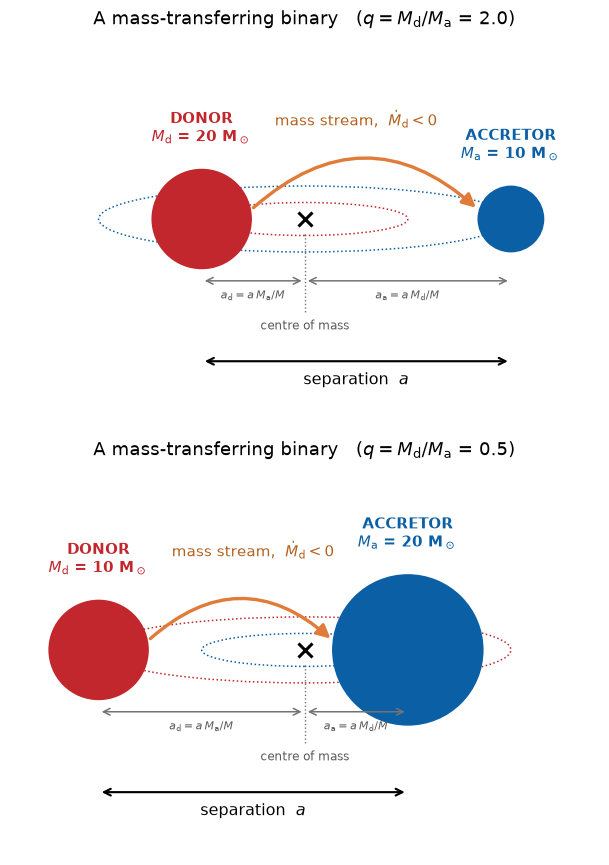

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Ellipse

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

C_D, C_A, CSYS = "#C1272D", "#0B5FA5", "#222222"   # donor = red, accretor = blue


def draw_binary_cartoon(M_d=20.0, M_a=10.0, ax=None):
    '''Cartoon of a mass-transferring binary, with the quantities used in the derivation.'''
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4.2))

    a = 1.0                              # draw everything in units of the separation
    M = M_d + M_a
    x_d, x_a = -a * M_a / M, a * M_d / M     # positions relative to the centre of mass
    r_d, r_a = 0.16, 0.16 * (M_a / M_d) ** 0.6   # radii purely for visual effect

    # orbits of the two stars about the centre of mass
    for x, col in [(x_d, C_D), (x_a, C_A)]:
        ax.add_patch(Ellipse((0, 0), 2 * abs(x), 2 * abs(x) * 0.16, fill=False,
                             ec=col, ls=":", lw=1))

    ax.add_patch(Circle((x_d, 0), r_d, color=C_D, zorder=3))
    ax.add_patch(Circle((x_a, 0), r_a, color=C_A, zorder=3))

    # the centre of mass, with a guide line down to its label
    ax.plot(0, 0, "x", color="k", ms=9, mew=2, zorder=4)
    ax.plot([0, 0], [-0.05, -0.30], color="0.45", lw=0.9, ls=":", zorder=1)
    ax.text(0, -0.325, "centre of mass", ha="center", va="top", fontsize=8, color="0.35")

    # the mass stream, drawn as a curved arrow from donor to accretor
    ax.add_patch(FancyArrowPatch((x_d + r_d, 0.03), (x_a - r_a, 0.03),
                                 connectionstyle="arc3,rad=-0.45",
                                 arrowstyle="-|>", mutation_scale=18, lw=2.2,
                                 color="#E07B39", zorder=2))
    ax.text((x_d + x_a) / 2, 0.30, r"mass stream,  $\dot{M}_{\rm d} < 0$",
            ha="center", fontsize=10, color="#B4601E")

    # the separation a
    ax.annotate("", xy=(x_d, -0.46), xytext=(x_a, -0.46),
                arrowprops=dict(arrowstyle="<->", color="k", lw=1.4))
    ax.text((x_d + x_a) / 2, -0.495, r"separation  $a$", ha="center", va="top", fontsize=10.5)

    # labels on the stars
    ax.text(x_d, r_d + 0.09, f"DONOR\n$M_{{\\rm d}}$ = {M_d:g} M$_\\odot$",
            ha="center", fontsize=10, color=C_D, weight="bold")
    ax.text(x_a, r_a + 0.09, f"ACCRETOR\n$M_{{\\rm a}}$ = {M_a:g} M$_\\odot$",
            ha="center", fontsize=10, color=C_A, weight="bold")

    # distances of each star from the centre of mass
    for x, lab in [(x_d, r"$a_{\rm d}= a\,M_{\rm a}/M$"), (x_a, r"$a_{\rm a}= a\,M_{\rm d}/M$")]:
        ax.annotate("", xy=(0, -0.20), xytext=(x, -0.20),
                    arrowprops=dict(arrowstyle="<->", color="0.45", lw=1))
        ax.text(x / 2, -0.23, lab, ha="center", va="top", fontsize=7.5, color="0.35")

    ax.set_xlim(-0.95, 0.95)
    ax.set_ylim(-0.66, 0.60)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f"A mass-transferring binary   ($q = M_{{\\rm d}}/M_{{\\rm a}}$ = {M_d/M_a:.1f})",
                 fontsize=12)
    return ax


fig, axes = plt.subplots(2, 1, figsize=(9, 8))
draw_binary_cartoon(M_d=20.0, M_a=10.0, ax=axes[0])   # donor heavier -> orbit will SHRINK
draw_binary_cartoon(M_d=10.0, M_a=20.0, ax=axes[1])   # donor lighter -> orbit will WIDEN
plt.tight_layout()
plt.show()

Both cartoons show the *same* physical process — mass flowing from the red star to the blue one.
The only difference is which one is heavier. By the end of Part 4 you will be able to say, without
computing anything, that the **top** binary's orbit is shrinking and the **bottom** one's is
widening.

<a id="part1"></a>
# Part 1 — Step 1: the orbital angular momentum

For a **circular** binary, the orbital angular momentum is

$$J = \mu \sqrt{G M a},$$

where $\mu = M_{\rm d} M_{\rm a}/M$ is the reduced mass and $M = M_{\rm d} + M_{\rm a}$.

<details>
<summary><b>Where does that come from?</b> (click to expand — you can safely skip this)</summary>

The two-body problem reduces to a single fictitious particle of mass $\mu$ orbiting at radius $a$
with angular velocity $\Omega$. Its angular momentum is $J = \mu a^2 \Omega$.
[Kepler's third law](https://en.wikipedia.org/wiki/Kepler%27s_laws_of_planetary_motion) gives
$\Omega^2 = GM/a^3$, so $\Omega = \sqrt{GM/a^3}$ and

$$J = \mu a^2 \sqrt{\frac{GM}{a^3}} = \mu\sqrt{GMa}. \qquad \checkmark$$

</details>

Substituting the reduced mass:

$$\boxed{\;J = \frac{M_{\rm d} M_{\rm a}}{M}\sqrt{G M a}\;}$$

**This single equation contains the whole result.** Everything below is just careful
differentiation. It is worth staring at it for a moment: $J$ depends on the *product* of the two
masses, on the *total* mass, and on $\sqrt{a}$. Mass transfer changes the first of those while
leaving the second alone — and something has to give.

<a id="part2"></a>
# Part 2 — Step 2: assume conservative mass transfer

We start with the simplest possible assumption, called **conservative** mass transfer:

1. **No mass leaves the system.** Everything the donor loses, the accretor gains:
   $$\mathrm{d}M = 0 \quad\Longleftrightarrow\quad \mathrm{d}M_{\rm a} = -\,\mathrm{d}M_{\rm d}.$$
2. **No angular momentum leaves the system:** $\mathrm{d}J = 0$.

> 🚧 **Is that realistic?** Often not — real mass transfer can be very non-conservative, with
> material escaping the binary entirely and carrying angular momentum with it. We relax both
> assumptions in [Part 6](#part6). But the conservative case is the right place to start: it is
> exactly solvable, and it already contains the essential physics.

The trick that makes this easy is the **logarithmic derivative**. Because $J$ is a *product* of
powers, taking $\ln$ first turns the product rule into a sum:

$$\ln J = \ln M_{\rm d} + \ln M_{\rm a} - \ln M + \tfrac12\left(\ln G + \ln M + \ln a\right)
        = \ln M_{\rm d} + \ln M_{\rm a} - \tfrac12 \ln M + \tfrac12 \ln a + \text{const}.$$

Differentiating,

$$\frac{\mathrm{d}J}{J} = \frac{\mathrm{d}M_{\rm d}}{M_{\rm d}}
                        + \frac{\mathrm{d}M_{\rm a}}{M_{\rm a}}
                        - \frac{1}{2}\frac{\mathrm{d}M}{M}
                        + \frac{1}{2}\frac{\mathrm{d}a}{a}.$$

Now impose the two assumptions. Total mass constant kills the third term ($\mathrm{d}M=0$), and
angular momentum conservation sets the left-hand side to zero:

$$0 = \frac{\mathrm{d}M_{\rm d}}{M_{\rm d}} + \frac{\mathrm{d}M_{\rm a}}{M_{\rm a}}
      + \frac{1}{2}\frac{\mathrm{d}a}{a},$$

which rearranges to

$$\frac{\mathrm{d}a}{a} = -2\left(\frac{\mathrm{d}M_{\rm d}}{M_{\rm d}}
                                + \frac{\mathrm{d}M_{\rm a}}{M_{\rm a}}\right).$$

> 💡 **Worth internalising:** logarithmic derivatives are *the* standard tool for this kind of
> problem, and you will meet them constantly in binary evolution. Any time you see a relation
> that is a product of powers, take $\ln$ before you differentiate.

<a id="part3"></a>
# Part 3 — Step 3: use mass conservation

Conservative transfer means $\mathrm{d}M_{\rm a} = -\,\mathrm{d}M_{\rm d}$. Substituting:

$$\frac{\mathrm{d}a}{a}
   = -2\left(\frac{\mathrm{d}M_{\rm d}}{M_{\rm d}} - \frac{\mathrm{d}M_{\rm d}}{M_{\rm a}}\right)
   = -2\,\mathrm{d}M_{\rm d}\left(\frac{1}{M_{\rm d}} - \frac{1}{M_{\rm a}}\right).$$

Putting the bracket over a common denominator, $\frac{1}{M_{\rm d}} - \frac{1}{M_{\rm a}}
= \frac{M_{\rm a}-M_{\rm d}}{M_{\rm d}M_{\rm a}}$, so

$$\boxed{\;\frac{\mathrm{d}a}{a}
 = 2\,\mathrm{d}M_{\rm d}\,\frac{M_{\rm d}-M_{\rm a}}{M_{\rm d}M_{\rm a}}\;}$$

or, dividing by $\mathrm{d}t$,

$$\frac{\dot a}{a} = 2\,\dot M_{\rm d}\left(\frac{M_{\rm d}-M_{\rm a}}{M_{\rm d}M_{\rm a}}\right).$$

That is the standard result, and it is already enough to answer the question. But there is a
tidier way to write it.

<a id="part4"></a>
# Part 4 — Step 4: the answer, and what it means

## 4.1 The mass-ratio form

Define the mass ratio **donor over accretor**:

$$q \equiv \frac{M_{\rm donor}}{M_{\rm accretor}} = \frac{M_{\rm d}}{M_{\rm a}}
\qquad\Longrightarrow\qquad M_{\rm d} = q\,M_{\rm a}.$$

Substituting into the boxed result:

$$\frac{\mathrm{d}a}{a}
 = 2\,\mathrm{d}M_{\rm d}\,\frac{M_{\rm d}-M_{\rm a}}{M_{\rm d}M_{\rm a}}
 = 2\,\frac{\mathrm{d}M_{\rm d}}{M_{\rm d}}\cdot\frac{M_{\rm d}-M_{\rm a}}{M_{\rm a}}
 = 2\,\frac{\mathrm{d}M_{\rm d}}{M_{\rm d}}\,\big(q - 1\big).$$

$$\boxed{\;\frac{\mathrm{d}a}{a} = 2\,\frac{\mathrm{d}M_{\rm d}}{M_{\rm d}}\,(q-1),
\qquad q = \frac{M_{\rm d}}{M_{\rm a}}\;}$$

Equivalently, and often the most useful form of all,

$$\frac{\mathrm{d}\ln a}{\mathrm{d}\ln M_{\rm d}} = 2\,(q-1).$$

---

> ## ⚠️ The single most common mistake: which $q$?
>
> **There is no universal convention for $q$, and the sign of this result flips if you pick the
> other one.** Before using *any* formula from *any* paper, check which definition it uses.
>
> | Convention | Definition | Orbit shrinks when | Where you'll meet it |
> |---|---|---|---|
> | **This notebook**, Pols' notes | $q = M_{\rm donor}/M_{\rm accretor}$ | $q > 1$ | binary-evolution theory |
> | Flipped | $q = M_{\rm accretor}/M_{\rm donor}$ | $q < 1$ | also common in theory papers! |
> | Observational GW | $q = m_2/m_1 \le 1$, ordered by mass | *(not about donors at all)* | LIGO papers, [Notebook 2](analysing_a_population_of_gravitational_wave_sources.ipynb) |
>
> The physics never changes — only the label. If you ever find yourself concluding that mass
> transfer from a heavy star onto a light one *widens* the orbit, you have almost certainly
> tripped over this. Go back and check your $q$.

## 4.2 Reading off the sign

The donor is losing mass, so **$\mathrm{d}M_{\rm d} < 0$ always**. That factor is negative no
matter what. So the sign of $\mathrm{d}a$ is set entirely by the sign of $(q-1)$:

$$\frac{\mathrm{d}a}{a} = 2\underbrace{\frac{\mathrm{d}M_{\rm d}}{M_{\rm d}}}_{<\,0}(q-1)$$

**Case 1 — the donor is the heavier star** ($M_{\rm d} > M_{\rm a}$, i.e. $q > 1$):
$$(q-1) > 0 \quad\Longrightarrow\quad \mathrm{d}a < 0 \quad\Longrightarrow\quad
\textbf{the orbit shrinks.} \;\downarrow$$

**Case 2 — the donor is the lighter star** ($M_{\rm d} < M_{\rm a}$, i.e. $q < 1$):
$$(q-1) < 0 \quad\Longrightarrow\quad \mathrm{d}a > 0 \quad\Longrightarrow\quad
\textbf{the orbit widens.} \;\uparrow$$

**Case 3 — equal masses** ($q = 1$): $\mathrm{d}a = 0$. The separation is momentarily stationary.
As we will see in §5.3, this is a genuine **minimum**: the orbit shrinks up to this point and
widens afterwards.

## 4.3 The physical intuition (learn this, not the algebra)

Here is the one-sentence version, which is worth far more than remembering the formula.

For fixed total mass $M$, the angular momentum is

$$J \;\propto\; M_{\rm d}M_{\rm a}\sqrt{a}.$$

The product $M_{\rm d}M_{\rm a}$ is **maximised when the two stars have equal masses** (for a
fixed sum). And $J$ must stay constant. So:

- Mass flowing from the **heavier** star to the lighter one makes the masses **more equal**
  → $M_{\rm d}M_{\rm a}$ **increases** → $\sqrt{a}$ must **decrease** → 🔻 **the orbit shrinks.**
- Mass flowing from the **lighter** star to the heavier one makes the masses **more unequal**
  → $M_{\rm d}M_{\rm a}$ **decreases** → $\sqrt{a}$ must **increase** → 🔺 **the orbit widens.**

That's it. The orbit is doing whatever it must to keep $M_{\rm d}M_{\rm a}\sqrt{a}$ constant.

> 🔁 **Connecting back to Notebook 1.** In that binary, star 1 (35 $M_\odot$) started transferring
> onto star 2 (31 $M_\odot$). Initially $q>1$, so the orbit shrank. But star 1 kept losing mass, the
> mass ratio **flipped** partway through, and from then on $q<1$ and the orbit **widened** — which
> is why you saw $a$ grow from ~790 to ~2000 $R_\odot$ overall. The widening you observed is the
> *second half* of the story you are deriving here.

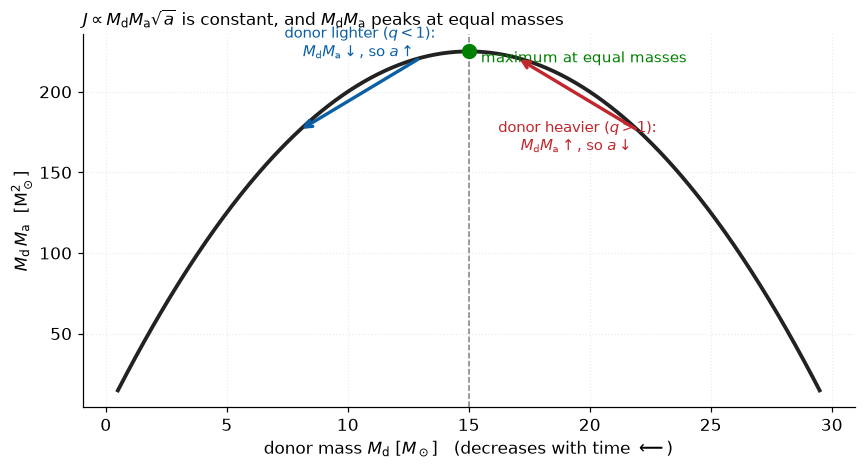

In [2]:
# The intuition of section 4.3, as a picture: for fixed total mass, where is M_d * M_a largest?
M_total = 30.0
M_d = np.linspace(0.5, 29.5, 400)
M_a = M_total - M_d

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(M_d, M_d * M_a, color=CSYS, lw=2.5)
ax.axvline(M_total / 2, color="grey", ls="--", lw=1)
ax.plot(M_total / 2, (M_total / 2) ** 2, "o", color="green", ms=9, zorder=3)
ax.text(M_total / 2 + 0.5, (M_total / 2) ** 2 * 0.97,
        "maximum at equal masses", fontsize=10, color="green")

# arrows showing which way mass transfer moves you along this curve
ax.annotate("", xy=(17, 17 * 13), xytext=(22, 22 * 8),
            arrowprops=dict(arrowstyle="->", color=C_D, lw=2.2))
ax.text(19.5, 19.5 * 10.5 - 22, "donor heavier ($q>1$):\n$M_{\\rm d}M_{\\rm a}\\uparrow$, so $a\\downarrow$",
        fontsize=9.5, color=C_D, ha="center", va="top")
ax.annotate("", xy=(8, 8 * 22), xytext=(13, 13 * 17),
            arrowprops=dict(arrowstyle="->", color=C_A, lw=2.2))
ax.text(10.5, 10.5 * 19.5 + 14, "donor lighter ($q<1$):\n$M_{\\rm d}M_{\\rm a}\\downarrow$, so $a\\uparrow$",
        fontsize=9.5, color=C_A, ha="center", va="bottom")

ax.set_xlabel(r"donor mass $M_{\rm d}$ [$M_\odot$]   (decreases with time $\longleftarrow$)")
ax.set_ylabel(r"$M_{\rm d}\,M_{\rm a}$  [M$_\odot^2$]")
ax.set_title(r"$J \propto M_{\rm d}M_{\rm a}\sqrt{a}$ is constant, and $M_{\rm d}M_{\rm a}$ peaks "
             r"at equal masses", loc="left", fontsize=11)
plt.tight_layout()
plt.show()

Mass transfer always moves you **leftwards** along this curve (the donor only ever loses mass).
Starting on the right of the peak you climb *up* — so $a$ must fall. Once past the peak you come
back *down* — so $a$ rises again.

<a id="part5"></a>
# Part 5 — Now in Python

## 5.1 The functions

Three small functions: the angular momentum itself, the orbital response, and — because the
conservative case is exactly solvable — a **closed-form** expression for the separation.

In [3]:
G_SI, MSUN, RSUN = 6.67430e-11, 1.98892e30, 6.957e8


def orbital_angular_momentum(M_d, M_a, a_rsun):
    '''Orbital angular momentum of a circular binary, in SI units (kg m^2 / s).

    M_d, M_a : donor and accretor mass in solar masses
    a_rsun   : separation in solar radii
    '''
    M_d, M_a, a = np.asarray(M_d) * MSUN, np.asarray(M_a) * MSUN, np.asarray(a_rsun) * RSUN
    M = M_d + M_a
    mu = M_d * M_a / M
    return mu * np.sqrt(G_SI * M * a)


def dlna_dlnMd(q):
    '''d ln(a) / d ln(M_donor) for CONSERVATIVE mass transfer.

    q = M_donor / M_accretor.  Returns 2*(q - 1).

    Sign reminder: the donor loses mass, so d ln M_d < 0. Therefore
        q > 1  ->  this is positive -> d ln a < 0 -> orbit SHRINKS
        q < 1  ->  this is negative -> d ln a > 0 -> orbit WIDENS
    '''
    return 2.0 * (np.asarray(q, dtype=float) - 1.0)


def separation_conservative(M_d, M_d_init, M_a_init, a_init=1.0):
    '''EXACT separation during conservative mass transfer.

    Because both M and J are constant, J = (M_d M_a / M) sqrt(GMa) implies
    a is proportional to 1 / (M_d M_a)^2, so

        a / a_init = ( M_d_init * M_a_init / (M_d * M_a) )^2 .

    M_d      : current donor mass (may be an array)
    a_init   : separation at the start; the default of 1.0 returns a / a_init.
    '''
    M_total = M_d_init + M_a_init
    M_a = M_total - np.asarray(M_d, dtype=float)      # conservative: what one loses the other gains
    return a_init * (M_d_init * M_a_init / (np.asarray(M_d, dtype=float) * M_a)) ** 2


def period_conservative(M_d, M_d_init, M_a_init, P_init=1.0):
    '''Orbital period during conservative mass transfer, from Kepler's third law.

    P^2 = 4 pi^2 a^3 / (G M) and M is constant, so P is proportional to a^(3/2), giving
        P / P_init = ( M_d_init * M_a_init / (M_d * M_a) )^3 .
    '''
    return P_init * (separation_conservative(M_d, M_d_init, M_a_init, 1.0)) ** 1.5


print("d ln a / d ln M_d  for a few mass ratios (conservative):")
for q in [0.25, 0.5, 1.0, 2.0, 4.0]:
    val = dlna_dlnMd(q)
    verdict = "orbit WIDENS " if val < 0 else ("stationary   " if val == 0 else "orbit SHRINKS")
    print(f"   q = {q:4.2f} ->  2(q-1) = {val:+6.2f}   {verdict}")

d ln a / d ln M_d  for a few mass ratios (conservative):
   q = 0.25 ->  2(q-1) =  -1.50   orbit WIDENS 
   q = 0.50 ->  2(q-1) =  -1.00   orbit WIDENS 
   q = 1.00 ->  2(q-1) =  +0.00   stationary   
   q = 2.00 ->  2(q-1) =  +2.00   orbit SHRINKS
   q = 4.00 ->  2(q-1) =  +6.00   orbit SHRINKS


## 5.2 Check the algebra numerically

Never trust a derivation you have not tested. We have two independent routes to the same answer:

1. the **closed form** `separation_conservative`, and
2. **numerically integrating** the differential relation
   $\mathrm{d}\ln a/\mathrm{d}\ln M_{\rm d} = 2(q-1)$ step by step.

If the algebra in Parts 1–4 is right, these must agree. We also check directly that $J$ and $M$
come out constant, which is what we assumed in the first place.

In [4]:
M_d_init, M_a_init = 20.0, 10.0          # donor starts as the heavier star: q = 2
M_total = M_d_init + M_a_init

# route 1: the closed form
M_d_grid = np.linspace(M_d_init, 5.0, 2001)          # donor loses mass, 20 -> 5 Msun
a_closed = separation_conservative(M_d_grid, M_d_init, M_a_init, a_init=1.0)

# route 2: integrate d(ln a) = 2(q-1) d(ln M_d) numerically along the same grid
M_a_grid = M_total - M_d_grid
q_grid = M_d_grid / M_a_grid
integrand = dlna_dlnMd(q_grid) / M_d_grid            # d(ln a)/dM_d
ln_a_numeric = np.concatenate([[0.0], np.cumsum(
    0.5 * (integrand[1:] + integrand[:-1]) * np.diff(M_d_grid))])   # trapezoidal rule
a_numeric = np.exp(ln_a_numeric)

print(f"max |closed form - numerical| / closed form : "
      f"{np.max(np.abs(a_numeric - a_closed) / a_closed):.2e}   (should be ~0)")

# and confirm the two things we ASSUMED are actually conserved by the closed-form solution
J = orbital_angular_momentum(M_d_grid, M_a_grid, a_closed * 100.0)   # a_init = 100 Rsun, say
print(f"total mass:        {M_total:.4f} Msun everywhere "
      f"(spread {np.ptp(M_d_grid + M_a_grid):.1e})")
print(f"angular momentum:  fractional spread = {np.ptp(J) / np.mean(J):.2e}   (should be ~0)")

max |closed form - numerical| / closed form : 2.73e-07   (should be ~0)
total mass:        30.0000 Msun everywhere (spread 0.0e+00)
angular momentum:  fractional spread = 9.19e-16   (should be ~0)


Both checks pass, so the algebra is sound. Now let's look at what it *does*.

<a id="part5.3"></a>
## 5.3 The money plot: shrink, then widen

Take a binary and transfer mass conservatively from the donor. Follow the separation. Because the
donor starts heavy and steadily gets lighter, **it crosses $q=1$ partway through** — so every such
binary shrinks first and widens afterwards.

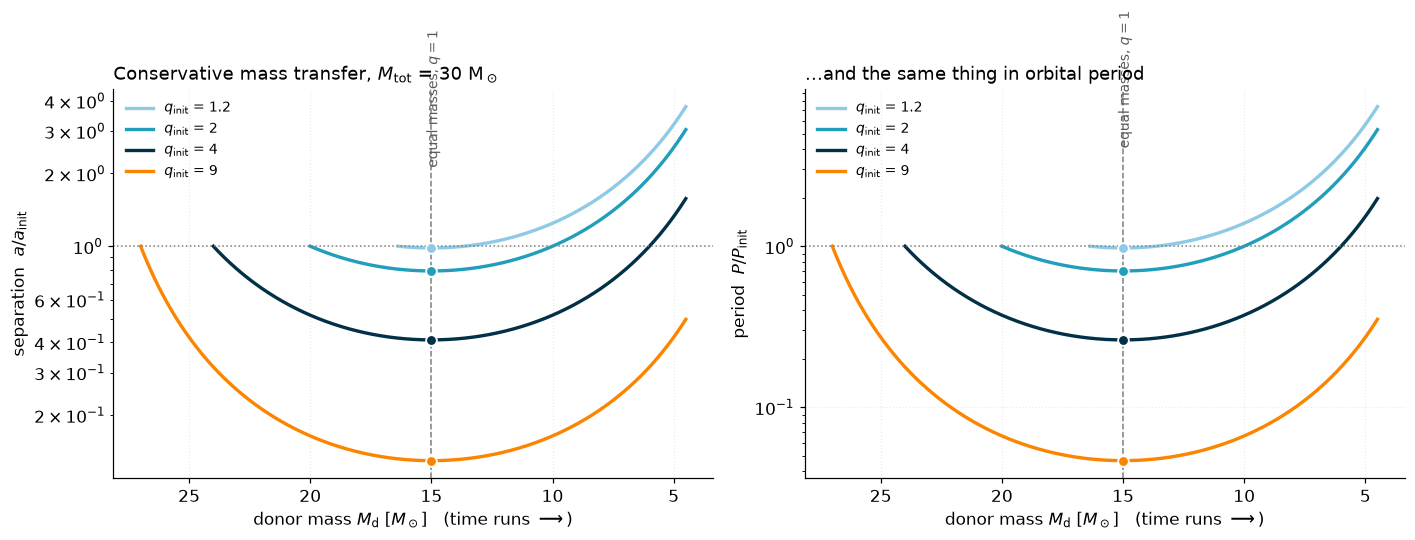

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
M_total = 30.0

for q_init, col in zip([1.2, 2.0, 4.0, 9.0], ["#8ECAE6", "#219EBC", "#023047", "#FB8500"]):
    M_d_i = M_total * q_init / (1 + q_init)
    M_a_i = M_total - M_d_i
    M_d = np.linspace(M_d_i, 0.15 * M_total, 600)     # transfer until the donor is nearly gone

    a_over_ai = separation_conservative(M_d, M_d_i, M_a_i)
    P_over_Pi = period_conservative(M_d, M_d_i, M_a_i)

    for ax, y in [(axes[0], a_over_ai), (axes[1], P_over_Pi)]:
        ax.plot(M_d, y, color=col, lw=2.2, label=f"$q_{{\\rm init}}$ = {q_init:g}")
        # mark the moment the masses become equal -- the minimum
        if M_d.min() < M_total / 2 < M_d.max():
            y_eq = np.interp(M_total / 2, M_d[::-1], y[::-1])
            ax.plot(M_total / 2, y_eq, "o", color=col, ms=7, mec="white", mew=1.2, zorder=4)

for ax, lab, sym in [(axes[0], r"separation  $a / a_{\rm init}$", "a"),
                     (axes[1], r"period  $P / P_{\rm init}$", "P")]:
    ax.axhline(1.0, color="grey", lw=1, ls=":")
    ax.axvline(M_total / 2, color="grey", lw=1, ls="--")
    ax.text(M_total / 2 - 0.4, ax.get_ylim()[1] * 0.55, "equal masses, $q=1$",
            rotation=90, fontsize=9, ha="right", color="0.35")
    ax.set_yscale("log")
    ax.set_xlabel(r"donor mass $M_{\rm d}$ [$M_\odot$]   (time runs $\longrightarrow$)")
    ax.set_ylabel(lab)
    ax.invert_xaxis()          # so that time runs left to right
    ax.legend(fontsize=9, loc="upper left")

axes[0].set_title(f"Conservative mass transfer, $M_{{\\rm tot}}$ = {M_total:g} M$_\\odot$",
                  loc="left", fontsize=12)
axes[1].set_title("...and the same thing in orbital period", loc="left", fontsize=12)
plt.tight_layout()
plt.show()

### 📖 What to notice

- **Every curve dips and then climbs.** The circle marks $q=1$, and it sits exactly at the
  minimum of each curve — as Case 3 in §4.2 predicted. Mass transfer from the heavier star
  shrinks the orbit; once the mass ratio has flipped, continued transfer widens it again.
- **The more extreme the initial mass ratio, the deeper the dip and the bigger the final
  widening.** A binary starting at $q=9$ shrinks by well over an order of magnitude before
  turning around.
- **The final separation can be much larger than the initial one.** If the donor is stripped far
  past equal masses, the orbit ends up *wider* than it started — which is exactly what you saw in
  Notebook 1.
- **The period swings even harder than the separation** ($P \propto a^{3/2}$), which matters
  because the period is what observers actually measure.

> ⚠️ **A caveat about the deep dips.** The curves keep shrinking as long as $q>1$, but a real
> binary may not survive that. If the orbit shrinks *faster than the donor can shrink inside its
> Roche lobe*, mass transfer runs away — and you get a **common envelope** instead of the smooth
> curve plotted here. [Part 7](#part7) is about exactly that boundary.

## 5.4 The orbital response as a function of $q$ alone

The cleanest summary of the whole result: plot $\mathrm{d}\ln a/\mathrm{d}\ln M_{\rm d} = 2(q-1)$
and read off the sign.

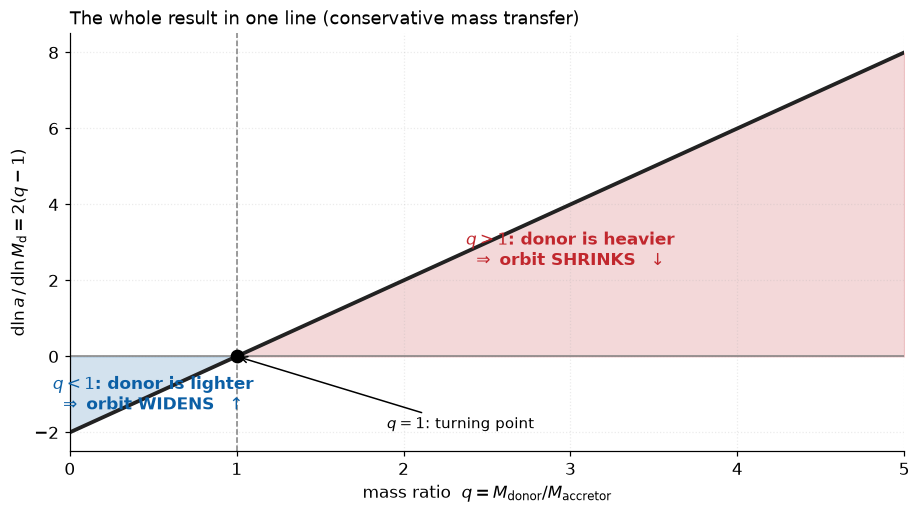

In [6]:
q = np.linspace(0, 5, 500)
response = dlna_dlnMd(q)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(q, response, color=CSYS, lw=2.5)
ax.axhline(0, color="grey", lw=1)
ax.axvline(1, color="grey", lw=1, ls="--")

ax.fill_between(q, response, 0, where=(q > 1), color=C_D, alpha=0.18)
ax.fill_between(q, response, 0, where=(q < 1), color=C_A, alpha=0.18)

ax.text(3.0, 2.4, "$q>1$: donor is heavier\n$\\Rightarrow$ orbit SHRINKS  $\\downarrow$",
        fontsize=11, color=C_D, ha="center", weight="bold")
ax.text(0.5, -1.4, "$q<1$: donor is lighter\n$\\Rightarrow$ orbit WIDENS  $\\uparrow$",
        fontsize=11, color=C_A, ha="center", weight="bold")
ax.plot(1, 0, "o", color="k", ms=8, zorder=4)
ax.annotate("$q=1$: turning point", xy=(1, 0), xytext=(1.9, -1.9), fontsize=10,
            arrowprops=dict(arrowstyle="->", color="k", lw=1))

ax.set_xlabel(r"mass ratio  $q = M_{\rm donor}/M_{\rm accretor}$")
ax.set_ylabel(r"$\mathrm{d}\ln a\,/\,\mathrm{d}\ln M_{\rm d} = 2(q-1)$")
ax.set_title("The whole result in one line (conservative mass transfer)", loc="left", fontsize=12)
ax.set_xlim(0, 5)
plt.tight_layout()
plt.show()

> 🧠 **Remember the axes, not the formula.** If you can reconstruct this picture — negative
> response below $q=1$, positive above, zero at 1, and the reminder that
> $\mathrm{d}\ln M_{\rm d}$ is itself negative — you can re-derive the sign any time you need it.

<a id="part6"></a>
# Part 6 — Relaxing the assumptions: non-conservative mass transfer

Real mass transfer is usually **not** conservative. The accretor may not be able to swallow
everything thrown at it: it can be spun up to break-up, or the incoming material can be blown
away by radiation. Whatever escapes takes angular momentum with it, and that changes the orbit
too — usually by shrinking it.

We parametrise our ignorance with two numbers, following
[Soberman, Phinney & van den Heuvel (1997)](https://arxiv.org/abs/astro-ph/9703016):

| Parameter | Meaning | Conservative limit |
|---|---|---|
| $\beta$ | **accretion efficiency**: the fraction of the transferred mass that the accretor actually keeps, $\dot M_{\rm a} = -\beta\,\dot M_{\rm d}$. $\beta=1$ is fully conservative, $\beta=0$ means nothing is accreted. | $\beta = 1$ |
| $\gamma$ | the **specific angular momentum carried away** by the escaping matter, in units of the binary's average specific angular momentum $J/M$. | *(irrelevant, nothing escapes)* |

Redoing Part 2 with $\mathrm{d}M \ne 0$ and $\mathrm{d}J \ne 0$ (the algebra is the same
logarithmic derivative, just with more terms surviving) gives the general result:

$$\boxed{\;\frac{\dot a}{a} = -2\,\frac{\dot M_{\rm d}}{M_{\rm d}}
\left[\,1 \;-\; \beta\,q \;-\; (1-\beta)\left(\gamma + \tfrac12\right)\frac{q}{1+q}\,\right]\;}$$

using $M_{\rm d}/M = q/(1+q)$.

<details>
<summary><b>Check the conservative limit</b></summary>

Set $\beta=1$: the last term vanishes and the bracket becomes $(1-q)$, so
$\dot a/a = -2(\dot M_{\rm d}/M_{\rm d})(1-q) = 2(\dot M_{\rm d}/M_{\rm d})(q-1)$ — exactly the
boxed result of §4.1. ✔️ We verify this numerically in the next cell too.

</details>

### Two standard choices for $\gamma$

The value of $\gamma$ depends on *where* the mass leaves from:

- **Jeans mode** (a fast, spherically symmetric wind straight off the donor). The matter leaves
  carrying the donor's own specific angular momentum, which works out to
  $$\gamma_{\rm Jeans} = \frac{M_{\rm a}}{M_{\rm d}} = \frac{1}{q}.$$
  This is the *gentlest* way to lose mass — it barely shrinks the orbit, and can even widen it.
- **Isotropic re-emission** (matter travels to the accretor, then is blasted away from *its*
  vicinity — think of a bright accreting object driving a wind). Now it carries the accretor's
  specific angular momentum:
  $$\gamma_{\rm iso} = \frac{M_{\rm d}}{M_{\rm a}} = q.$$
  When the donor is the heavier star this is much more damaging, because the accretor sits far
  from the centre of mass and so its material carries a lot of angular momentum per unit mass.

There are others in the literature (a circumbinary "ring", or the common-envelope $\gamma$
formalism), all handled by the same equation with a different $\gamma$.

In [7]:
def dlna_dlnMd_general(q, beta=1.0, gamma=None, mode=None):
    '''d ln(a) / d ln(M_donor) for NON-conservative mass transfer.

    q     : M_donor / M_accretor
    beta  : accretion efficiency; fraction of transferred mass retained (1 = conservative)
    gamma : specific angular momentum of the escaping matter, in units of J/M.
    mode  : shortcut for the two standard prescriptions; overrides `gamma`.
              "jeans"     -> gamma = 1/q   (fast wind from the donor)
              "isotropic" -> gamma = q     (re-emitted from near the accretor)

    Same sign convention as dlna_dlnMd(): multiply by d ln M_d (which is < 0) to get d ln a.
    '''
    q = np.asarray(q, dtype=float)
    if mode == "jeans":
        gamma = 1.0 / q
    elif mode == "isotropic":
        gamma = q
    elif mode is not None:
        raise ValueError("mode must be 'jeans', 'isotropic', or None")
    if gamma is None:
        gamma = 0.0                      # only reached when beta == 1, where gamma drops out
    return -2.0 * (1.0 - beta * q - (1.0 - beta) * (gamma + 0.5) * q / (1.0 + q))


# --- verify it reduces to the conservative formula when beta = 1 ------------------
q_test = np.linspace(0.05, 6, 200)
err = np.max(np.abs(dlna_dlnMd_general(q_test, beta=1.0) - dlna_dlnMd(q_test)))
print(f"beta = 1 reproduces the conservative result to {err:.2e}   (should be ~0)")

print("\nd ln a / d ln M_d at q = 3 (donor 3x heavier than accretor):")
for label, kw in [("fully conservative      ", dict(beta=1.0)),
                  ("half accreted, Jeans    ", dict(beta=0.5, mode="jeans")),
                  ("half accreted, isotropic", dict(beta=0.5, mode="isotropic")),
                  ("nothing accreted, Jeans ", dict(beta=0.0, mode="jeans")),
                  ("nothing accreted, iso.  ", dict(beta=0.0, mode="isotropic"))]:
    v = float(dlna_dlnMd_general(3.0, **kw))
    print(f"   {label} : {v:+6.2f}  -> orbit {'SHRINKS' if v > 0 else 'WIDENS '}")

beta = 1 reproduces the conservative result to 0.00e+00   (should be ~0)

d ln a / d ln M_d at q = 3 (donor 3x heavier than accretor):
   fully conservative       :  +4.00  -> orbit SHRINKS
   half accreted, Jeans     :  +1.62  -> orbit SHRINKS
   half accreted, isotropic :  +3.62  -> orbit SHRINKS
   nothing accreted, Jeans  :  -0.75  -> orbit WIDENS 
   nothing accreted, iso.   :  +3.25  -> orbit SHRINKS


## 6.1 How much does non-conservation matter?

The interesting question is where the **turning point** moves. In the conservative case the orbit
switches from shrinking to widening exactly at $q=1$. With mass loss, that critical mass ratio
shifts — and for isotropic re-emission it shifts a *lot*.

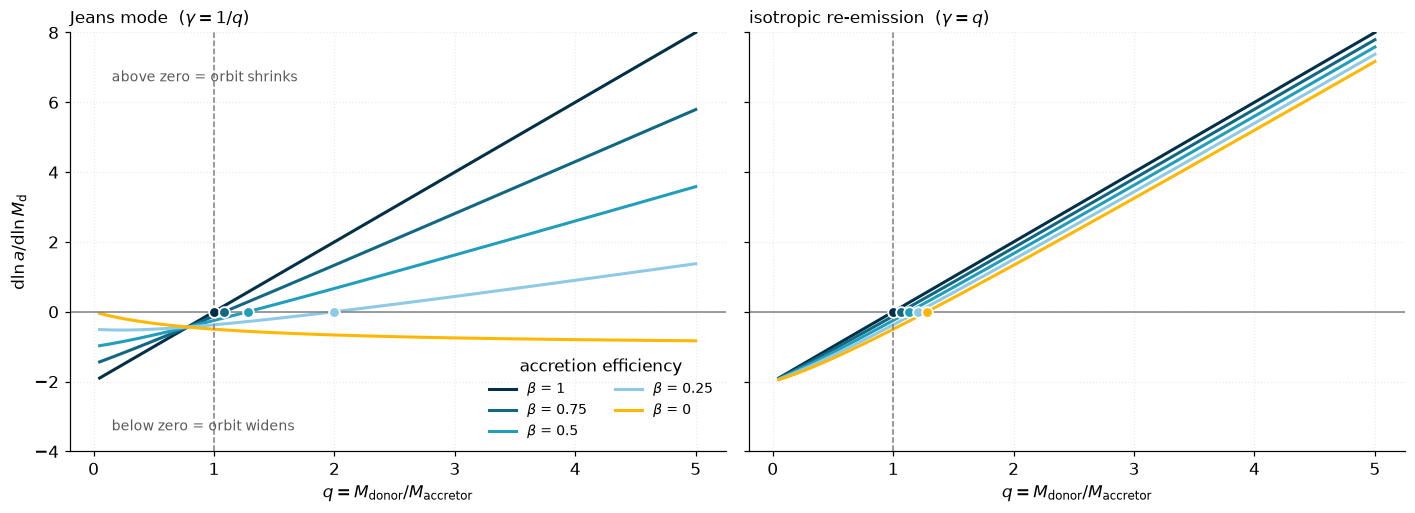

Critical mass ratio: the orbit shrinks above it and widens below it.

  beta     q_crit (Jeans)     q_crit (isotropic)
------------------------------------------------
  1.00              1.000                  1.000
  0.75              1.087                  1.064
  0.50              1.281                  1.133
  0.25              2.000                  1.205
  0.00      always widens                  1.281


In [8]:
def critical_q(beta, mode, q_lo=1e-3, q_hi=50.0, tol=1e-10):
    '''Find the mass ratio at which the orbit switches between shrinking and widening.

    Solves d ln a / d ln M_d = 0 by bisection. Returns np.nan if there is no sign change
    in the bracket (i.e. the orbit responds the same way at all mass ratios).
    '''
    f = lambda q: float(dlna_dlnMd_general(q, beta=beta, mode=mode))
    if f(q_lo) * f(q_hi) > 0:
        return np.nan
    while q_hi - q_lo > tol:
        q_mid = 0.5 * (q_lo + q_hi)
        if f(q_lo) * f(q_mid) <= 0:
            q_hi = q_mid
        else:
            q_lo = q_mid
    return 0.5 * (q_lo + q_hi)


fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
q = np.linspace(0.05, 5, 400)

for ax, mode, title in [(axes[0], "jeans", r"Jeans mode  ($\gamma = 1/q$)"),
                        (axes[1], "isotropic", r"isotropic re-emission  ($\gamma = q$)")]:
    for beta, col in zip([1.0, 0.75, 0.5, 0.25, 0.0],
                         ["#023047", "#126782", "#219EBC", "#8ECAE6", "#FFB703"]):
        ax.plot(q, dlna_dlnMd_general(q, beta=beta, mode=mode), color=col, lw=2,
                label=f"$\\beta$ = {beta:g}")
        qc = critical_q(beta, mode)
        if np.isfinite(qc) and 0.05 < qc < 5:
            ax.plot(qc, 0, "o", color=col, ms=7, mec="white", mew=1.2, zorder=4)
    ax.axhline(0, color="grey", lw=1)
    ax.axvline(1, color="grey", lw=1, ls="--")
    ax.set_xlabel(r"$q = M_{\rm donor}/M_{\rm accretor}$")
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_ylim(-4, 8)

axes[0].set_ylabel(r"$\mathrm{d}\ln a / \mathrm{d}\ln M_{\rm d}$")
axes[0].legend(fontsize=9, ncol=2, title="accretion efficiency")
axes[0].text(0.15, -3.4, "below zero = orbit widens", fontsize=9, color="0.35")
axes[0].text(0.15, 6.6, "above zero = orbit shrinks", fontsize=9, color="0.35")
plt.tight_layout()
plt.show()

fmt = lambda x: "always widens" if not np.isfinite(x) else f"{x:.3f}"
print("Critical mass ratio: the orbit shrinks above it and widens below it.")
print(f"\n{'beta':>6s} {'q_crit (Jeans)':>18s} {'q_crit (isotropic)':>22s}")
print("-" * 48)
for beta in [1.0, 0.75, 0.5, 0.25, 0.0]:
    print(f"{beta:6.2f} {fmt(critical_q(beta, 'jeans')):>18s} "
          f"{fmt(critical_q(beta, 'isotropic')):>22s}")

### 📖 What to notice

- **The conservative curves ($\beta=1$, darkest) cross zero at exactly $q=1$**, as they must —
  that is the check from §4.1, now visible.
- **Two competing effects.** Mass *leaving the binary* tends to **widen** the orbit (there is less
  gravity holding it together); angular momentum *leaving with that mass* tends to **shrink** it.
  Every curve here is the outcome of that competition, and which one wins depends on $\gamma$.
- **Jeans mode is the gentle extreme.** A fast wind straight off the donor carries very little
  angular momentum, so the widening term dominates. At $\beta=0$ the orbit **always widens**,
  whatever the mass ratio — which is why the table below reports no critical $q$ for that case.
  (In fact $\beta=0$ Jeans mode gives exactly $a \propto 1/M$; you verify this in Exercise 5.)
- **Isotropic re-emission is the harsh extreme.** Matter ejected from near the accretor carries a
  lot of angular momentum, so the shrinking term nearly cancels the widening one. Its curves stay
  much closer to the conservative case — at $q=3$ and $\beta=0.5$ it gives
  $\mathrm{d}\ln a/\mathrm{d}\ln M_{\rm d} = +3.6$ against the conservative $+4.0$, whereas Jeans
  mode manages only $+1.6$. (Positive means shrinking — see the printout above.)
- **A result that may surprise you: at a given $q>1$, *fully conservative* transfer shrinks the
  orbit hardest of all**, and any mass loss softens that. Correspondingly the critical mass ratio
  moves *up* (a little for isotropic re-emission, a lot for Jeans mode) rather than down. If you
  expected non-conservation to always tighten orbits, this is worth sitting with — it is a good
  example of why it pays to write the formula down and evaluate it rather than reason from
  slogans.
- 💡 **This is why $\beta$ and the mass-loss mode are such consequential modelling choices.**
  Two population synthesis codes with identical stellar physics but different assumptions here
  will predict different numbers of merging binaries. Quantifying that spread across codes and
  assumptions is exactly what the GROWL catalog is for.

<a id="part7"></a>
# Part 7 — Advanced: why this decides whether mass transfer is *stable*

*This part is optional. Skip it happily if the previous parts were enough — but it is where the
payoff is, because it explains where common envelopes come from.*

Knowing how $a$ responds is only half the story. The question that actually decides a binary's
fate is:

> Once mass transfer starts, does it **settle down** or does it **run away**?

Mass transfer happens because the donor fills its Roche lobe. So we have to compare **two**
responses to the same small amount of transferred mass:

- **How the Roche lobe changes**, $\zeta_{\rm L} \equiv
  \dfrac{\mathrm{d}\ln R_{\rm L}}{\mathrm{d}\ln M_{\rm d}}$
- **How the donor star itself changes**, $\zeta_{\star} \equiv
  \dfrac{\mathrm{d}\ln R_{\rm d}}{\mathrm{d}\ln M_{\rm d}}$

Remember $\mathrm{d}\ln M_{\rm d} < 0$. The condition is:

$$\zeta_{\star} > \zeta_{\rm L} \;\Rightarrow\; \textbf{stable} \qquad\qquad
\zeta_{\star} < \zeta_{\rm L} \;\Rightarrow\; \textbf{unstable} \;\rightarrow\;
\text{common envelope}$$

In words: **if the donor shrinks inside its Roche lobe faster than the lobe shrinks around it,
mass transfer is self-limiting and stable. If the lobe closes in faster than the star can retreat,
more mass is driven through, which shrinks the lobe further, which drives more mass through — a
runaway.** That runaway is a
[common envelope](https://en.wikipedia.org/wiki/Common_envelope).

## 7.1 The Roche lobe radius

The Roche lobe has no simple closed form, but [Eggleton (1983)](https://ui.adsabs.harvard.edu/abs/1983ApJ...268..368E)
gives a fit accurate to better than 1% everywhere:

$$\frac{R_{\rm L}}{a} = \frac{0.49\,q^{2/3}}{0.6\,q^{2/3} + \ln\!\left(1+q^{1/3}\right)},
\qquad q = \frac{M_{\rm d}}{M_{\rm a}}$$

Note that $R_{\rm L}$ depends on **both** $a$ and $q$, and mass transfer changes both at once. So

$$\zeta_{\rm L} = \underbrace{\frac{\mathrm{d}\ln a}{\mathrm{d}\ln M_{\rm d}}}_{=\,2(q-1)}
 + \underbrace{\frac{\mathrm{d}\ln f}{\mathrm{d}\ln q}}_{\text{shape of the lobe}}
   \cdot\underbrace{\frac{\mathrm{d}\ln q}{\mathrm{d}\ln M_{\rm d}}}_{=\,1+q}$$

where $f(q) = R_{\rm L}/a$. (The $1+q$ comes from $q = M_{\rm d}/(M-M_{\rm d})$ at constant $M$.)
Rather than differentiate Eggleton's fit by hand — tedious and easy to get wrong — we do it
numerically.

In [9]:
def roche_lobe_over_a(q):
    '''Eggleton (1983) fit: R_Lobe / a for the star of mass ratio q = M_this / M_other.'''
    q = np.asarray(q, dtype=float)
    q13, q23 = q ** (1.0 / 3.0), q ** (2.0 / 3.0)
    return 0.49 * q23 / (0.6 * q23 + np.log(1.0 + q13))


def zeta_lobe(q, h=1e-5):
    '''d ln R_Lobe / d ln M_donor for conservative mass transfer.

    Combines the change in separation, 2(q-1), with the change in the lobe's shape.
    The dln f / dln q derivative is taken numerically (central difference in log q).
    '''
    q = np.asarray(q, dtype=float)
    lnq = np.log(q)
    dlnf_dlnq = (np.log(roche_lobe_over_a(np.exp(lnq + h)))
                 - np.log(roche_lobe_over_a(np.exp(lnq - h)))) / (2 * h)
    return dlna_dlnMd(q) + dlnf_dlnq * (1.0 + q)


# Sanity check: compare Eggleton's fit against the older Paczynski (1971) approximation
#     R_L/a = 0.462 (q/(1+q))^(1/3),
# which is only valid for q <~ 0.8. They should agree well there and diverge for large q.
print(f"{'q':>6s} {'Eggleton 1983':>15s} {'Paczynski 1971':>16s} {'difference':>12s}")
print("-" * 52)
for q_chk in [0.1, 0.3, 0.5, 0.8, 2.0, 5.0]:
    egg = float(roche_lobe_over_a(q_chk))
    pac = 0.462 * (q_chk / (1 + q_chk)) ** (1 / 3)
    note = "" if q_chk <= 0.8 else "  <- Paczynski not valid here"
    print(f"{q_chk:6.1f} {egg:15.4f} {pac:16.4f} {100*(pac-egg)/egg:11.1f}%{note}")

     q   Eggleton 1983   Paczynski 1971   difference
----------------------------------------------------
   0.1          0.2068           0.2077         0.5%
   0.3          0.2810           0.2834         0.8%
   0.5          0.3208           0.3203        -0.1%
   0.8          0.3598           0.3526        -2.0%
   2.0          0.4400           0.4036        -8.3%  <- Paczynski not valid here
   5.0          0.5208           0.4348       -16.5%  <- Paczynski not valid here


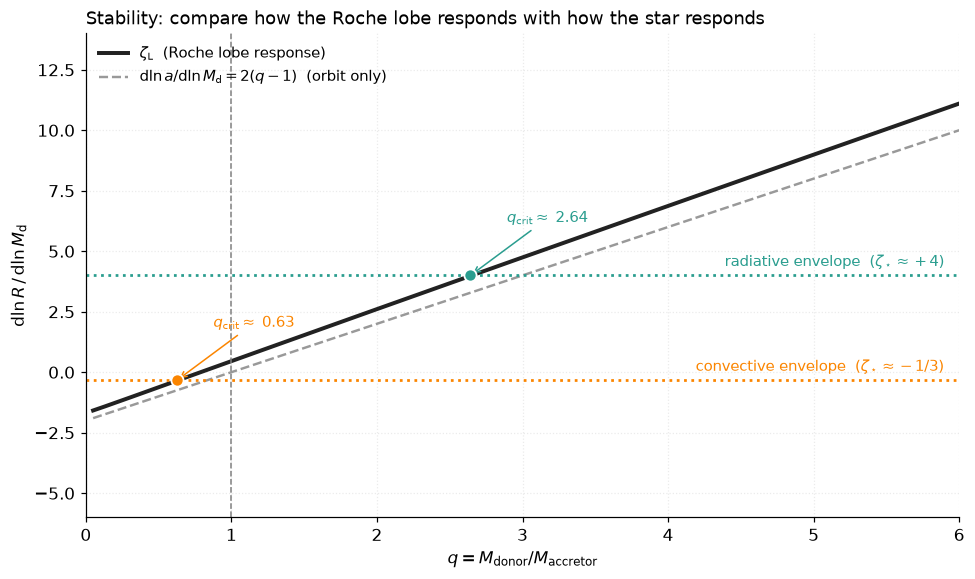

In [10]:
q = np.linspace(0.05, 6, 600)

fig, ax = plt.subplots(figsize=(9, 5.4))
ax.plot(q, zeta_lobe(q), color=CSYS, lw=2.6, label=r"$\zeta_{\rm L}$  (Roche lobe response)")
ax.plot(q, dlna_dlnMd(q), color="0.6", lw=1.6, ls="--",
        label=r"$\mathrm{d}\ln a/\mathrm{d}\ln M_{\rm d} = 2(q-1)$  (orbit only)")

# typical adiabatic responses of real stars, as horizontal reference lines
for zeta_star, name, col in [(-1.0 / 3.0, "convective envelope  ($\\zeta_\\star \\approx -1/3$)", "#FB8500"),
                             (4.0, "radiative envelope  ($\\zeta_\\star \\approx +4$)", "#2A9D8F")]:
    ax.axhline(zeta_star, color=col, lw=1.8, ls=":")
    # where does the Roche lobe response cross this star's response?
    cross = np.where(np.diff(np.sign(zeta_lobe(q) - zeta_star)))[0]
    for i in cross:
        qx = q[i]
        ax.plot(qx, zeta_star, "o", color=col, ms=8, mec="white", mew=1.2, zorder=5)
        ax.annotate(f"$q_{{\\rm crit}} \\approx$ {qx:.2f}", xy=(qx, zeta_star),
                    xytext=(qx + 0.25, zeta_star + 2.2), fontsize=9.5, color=col,
                    arrowprops=dict(arrowstyle="->", color=col, lw=1))
    ax.text(5.9, zeta_star + 0.35, name, fontsize=9.5, color=col, ha="right")

ax.axvline(1, color="grey", lw=1, ls="--")
ax.set_xlabel(r"$q = M_{\rm donor}/M_{\rm accretor}$")
ax.set_ylabel(r"$\mathrm{d}\ln R\,/\,\mathrm{d}\ln M_{\rm d}$")
ax.set_title("Stability: compare how the Roche lobe responds with how the star responds",
             loc="left", fontsize=12)
ax.set_ylim(-6, 14)
ax.set_xlim(0, 6)
ax.legend(fontsize=9.5, loc="upper left")
plt.tight_layout()
plt.show()

### 📖 How to read this

Pick a donor star, find its $\zeta_{\star}$ (a dotted horizontal line), and see where the black
$\zeta_{\rm L}$ curve crosses it. **To the left of the crossing the lobe response is below the
star's, so mass transfer is stable; to the right it is unstable.** That crossing point is the
**critical mass ratio** for that kind of star.

- **A star with a radiative envelope** ($\zeta_\star \approx +4$; roughly, a main-sequence or
  hot, compact donor) shrinks briskly when it loses mass. It tolerates a fairly extreme mass
  ratio before transfer runs away.
- **A star with a deep convective envelope** ($\zeta_\star \approx -1/3$; a red giant) actually
  **expands** as it loses mass — the notorious behaviour of convective stars, which follow
  roughly $R \propto M^{-1/3}$. It becomes unstable at a much lower mass ratio. Giant donors
  with heavier-than-companion masses are therefore prime common envelope candidates.

> ⚠️ **Do not over-trust the exact numbers.** The two $\zeta_\star$ values above are cartoon
> figures: real stars have $\zeta_\star$ that depends on mass, evolutionary state and how deep
> the convective envelope is, and there is an important distinction between the *adiabatic* and
> *thermal-timescale* responses that we have completely glossed over. The *structure* of the
> argument is solid and standard; the precise critical mass ratios are an active research topic
> and a major source of disagreement between population synthesis codes.

> 🔁 **Back to Notebook 1 one last time.** The binary there had a stable mass transfer episode
> first (main-sequence-ish donor, high $\zeta_\star$) and then, later, a common envelope when the
> donor was a **giant** with a convective envelope. You now know why those two episodes went
> differently.

<a id="exercises"></a>
# Part 8 — Exercises 🎓

**Pick whichever appeal to you — nobody is expected to do all of them.**

### Exercise 1 — Predict, then check (warm-up)

A binary has $M_{\rm d} = 8$ $M_\odot$ and $M_{\rm a} = 12$ $M_\odot$, separation 50 $R_\odot$.
Conservative mass transfer moves 3 $M_\odot$ from donor to accretor.

**Before running anything**, write down whether the orbit widens or shrinks and roughly by how
much. Then check with `separation_conservative`. Were you right?

#### Solution 1

Initially $q=8/12<1$, so donor mass loss **widens** the orbit. Afterwards $(M_{\rm d},M_{\rm a})=(5,15)\,M_\odot$. Conservation of mass and orbital angular momentum gives

$$\frac{a_{\rm f}}{a_{\rm i}}=\left(\frac{M_{\rm d,i}M_{\rm a,i}}{M_{\rm d,f}M_{\rm a,f}}\right)^2
=\left(\frac{8\times12}{5\times15}\right)^2=1.6384.$$

Thus $a_{\rm f}=81.92\,R_\odot$: an increase of $31.92\,R_\odot$, or $63.84\%$.

In [13]:
# check prediction: donor is lighter than accretor, so orbit should widen

M_d = 5.0
M_d_init = 8.0
M_a_init = 12.0
a_init = 50.0

a_fin = separation_conservative(M_d, M_d_init, M_a_init, a_init=a_init)
print(f"Final separation: {a_fin:.2f} R_sun; change: {100*(a_fin/a_init-1):.2f}%")
if a_fin > a_init:
    print("✅ Orbit widened, as expected.")
else:
    print("❌ Orbit shrank, which is NOT what we expected.")

Final separation: 81.92 R_sun; change: 63.84%
✅ Orbit widened, as expected.


### Exercise 2 — Find the minimum yourself

For a conservative binary with total mass $M$, prove **analytically** that $a$ is minimised when
$M_{\rm d} = M_{\rm a} = M/2$, and show that the minimum separation is

$$\frac{a_{\rm min}}{a_{\rm init}} = \left(\frac{4\,M_{\rm d,i}M_{\rm a,i}}{M^2}\right)^{2}.$$

Then verify it numerically against the curves in §5.3. *(Hint: $a \propto (M_{\rm d}M_{\rm a})^{-2}$
and $M_{\rm d}+M_{\rm a}$ is fixed — so you are just maximising a product with a fixed sum.)*

#### Solution 2

With $M$ fixed, $M_{\rm a}=M-M_{\rm d}$, so

$$M_{\rm d}M_{\rm a}=M_{\rm d}(M-M_{\rm d})
=\frac{M^2}{4}-\left(M_{\rm d}-\frac M2\right)^2\leq\frac{M^2}{4}.$$

Because $a\propto(M_{\rm d}M_{\rm a})^{-2}$, the maximum product gives the *minimum* separation, at $M_{\rm d}=M_{\rm a}=M/2$. Substitution yields

$$\boxed{\frac{a_{\rm min}}{a_{\rm init}}=
\left(\frac{4M_{\rm d,i}M_{\rm a,i}}{M^2}\right)^2
=\left(\frac{4q_{\rm init}}{(1+q_{\rm init})^2}\right)^2.}$$

The $q_{\rm init}=1.2,2,4,9$ curves in §5.3 reach their minima at $M_{\rm d}=15\,M_\odot$ when $M=30\,M_\odot$.

In [15]:
M_total_ex2 = 30.0

for q_initial in (1.2, 2.0, 4.0, 9.0):
    donor_initial = M_total_ex2*q_initial/(1+q_initial)
    accretor_initial = M_total_ex2 - donor_initial
    analytic = (4*donor_initial*accretor_initial/M_total_ex2**2)**2
    numerical = separation_conservative(M_total_ex2/2, donor_initial, accretor_initial)
    print(f"q_initial={q_initial:3.1f}: a_min/a_initial={analytic:.6f} (Numerical: {numerical:.6f})")

q_initial=1.2: a_min/a_initial=0.983539 (Numerical: 0.983539)
q_initial=2.0: a_min/a_initial=0.790123 (Numerical: 0.790123)
q_initial=4.0: a_min/a_initial=0.409600 (Numerical: 0.409600)
q_initial=9.0: a_min/a_initial=0.129600 (Numerical: 0.129600)


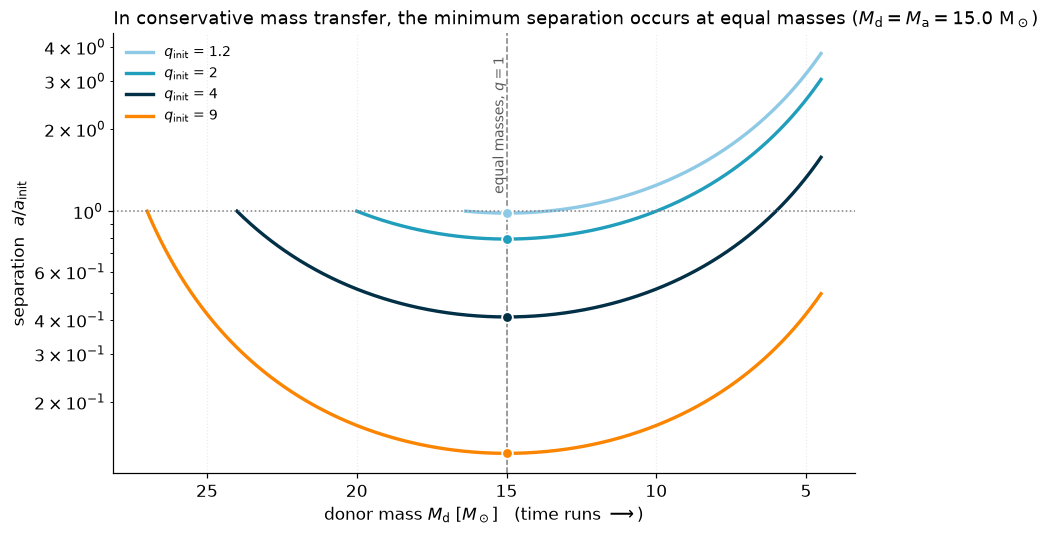

In [54]:
fig, ax = plt.subplots(figsize=(8, 5))
M_total = 30.0

for q_init, col in zip([1.2, 2.0, 4.0, 9.0], ["#8ECAE6", "#219EBC", "#023047", "#FB8500"]):
    M_d_i = M_total * q_init / (1 + q_init)
    M_a_i = M_total - M_d_i
    M_d = np.linspace(M_d_i, 0.15 * M_total, 600)     # transfer until the donor is nearly gone

    a_over_ai = separation_conservative(M_d, M_d_i, M_a_i)
    a_min = separation_conservative(M_total / 2, M_d_i, M_a_i) # claim: a_min occurs at M_d = M_a = M_total/2

    ax.plot(M_d, a_over_ai, color=col, lw=2.2, label=f"$q_{{\\rm init}}$ = {q_init:g}")
        
    # mark the moment the masses become equal -- the minimum
    ax.plot(M_total / 2, a_min, "o", color=col, ms=7, mec="white", mew=1.2, zorder=4)

ax.axhline(1.0, color="grey", lw=1, ls=":")
ax.axvline(M_total / 2, color="grey", lw=1, ls="--")
ax.text(M_total / 2 - 0.025, ax.get_ylim()[1] * 0.3, "equal masses, $q=1$",
            rotation=90, fontsize=9, ha="right", color="0.35")
ax.set_yscale("log")
ax.set_xlabel(r"donor mass $M_{\rm d}$ [$M_\odot$]   (time runs $\longrightarrow$)")
ax.set_ylabel(r"separation  $a / a_{\rm init}$")
ax.invert_xaxis()          # so that time runs left to right
ax.legend(fontsize=9, loc="upper left")

ax.set_title(f"In conservative mass transfer, the minimum separation occurs at equal masses ($M_{{\\rm d}} = M_{{\\rm a}} = {M_total/2:.1f}$ M$_\\odot$)",
                  loc="left", fontsize=12)
plt.tight_layout()
plt.show()

### Exercise 3 — How much widening can you get?

Starting from $q_{\rm init} = 5$, how much mass must the donor lose before the orbit returns to
its original separation? Express your answer as a fraction of the donor's initial mass, and check
it both algebraically and with the code.

#### Solution 3

For a conservative system, let $M_{\rm a,i}=m$ and $M_{\rm d,i}=5m$; then $M=6m$. We the solution such that $a_{\rm f}=a_{\rm i}$.

From the relation $ a \propto (M_d M_a)^{-2}$ we have,

$$ \frac{a_f}{a_i} = 1 = \left( \frac {M_{\rm d,i} M_{\rm a,i}}{M_{\rm d,f} M_{\rm a,f}} \right)^2 \Rightarrow 5m . m = M_{\rm d,f}(6m - M_{\rm d,f})$$

Factroization or applying the quadratic formula leads to two roots: $M_{\rm d,f} = (5m, m)$. We know that the first one reposnds to the initial condition, thus $M_{\rm d,f} = m$ is the correct answer for final donor mass at $a_{\rm f} = a_{\rm i}$.

So how much mass the the donor star loose? Change in its mass $\Delta M_{\rm d} = 5m - m = 4m$, i.e., it has lost **$4/5=80\%$** of its initial mass. 

The final mass ratio is then $1/5$, the reciprocal of its initial value.

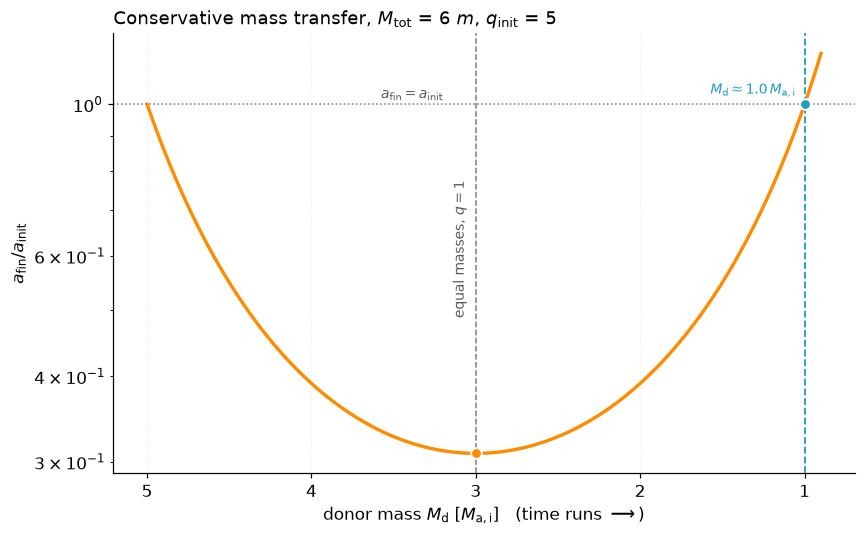

In [47]:
fig, ax = plt.subplots(figsize=(8, 5))

# everythin in units of m (initial mass of accretor)
M_total = 6.0
q_init = 5.0
M_d_i = M_total * q_init / (1 + q_init)
M_a_i = M_total - M_d_i
M_d = np.linspace(M_d_i, 0.15 * M_total, 600)

a_over_ai = separation_conservative(M_d, M_d_i, M_a_i)

ax.plot(M_d, a_over_ai, color="darkorange", lw=2.2)

# mark the moment the masses become equal -- the minimum
if M_d.min() < M_total / 2 < M_d.max():
    y_eq = np.interp(M_total / 2, M_d[::-1], a_over_ai[::-1])
    ax.plot(M_total / 2, y_eq, "o", color="darkorange", ms=7, mec="white", mew=1.2, zorder=4)


ax.axhline(1.0, color="grey", lw=1, ls=":")
ax.text(M_total / 2 + 0.2, 1.02, "$a_{\\rm fin} = a_{\\rm init}$",
        fontsize=9, ha="right", color="0.35")

ax.axvline(M_total / 2, color="grey", lw=1, ls="--")
ax.text(M_total / 2 + 0.05, ax.get_ylim()[1] * 0.4, "equal masses, $q=1$",
            rotation=90, fontsize=9, ha="right", color="0.35")


# --------- Find where the numerical curve crosses a/a_i = 1 -------------
difference = a_over_ai - 1.0

# Find consecutive points between which the sign changes
crossing_indices = np.where(difference[:-1] * difference[1:] < 0)[0]

if len(crossing_indices) > 0:
    # Select the later crossing, excluding the initial point
    i = crossing_indices[-1]

    # Linearly interpolate between the two surrounding data points
    M1, M2 = M_d[i], M_d[i + 1]
    y1, y2 = a_over_ai[i], a_over_ai[i + 1]

    M_d_cross = M1 + (1.0 - y1) * (M2 - M1) / (y2 - y1)

    # Add vertical line at the numerically determined crossing
    ax.axvline(M_d_cross, color="#219EBC", lw=1.2, ls="--")

    # Mark the crossing
    ax.plot(M_d_cross, 1.0,"o", color="#219EBC", ms=7, mec="white", mew=1.2, zorder=5)

    ax.text( M_d_cross + 0.05, 1.02,
        rf"$M_{{\rm d}}\approx {M_d_cross:.1f}\,M_{{\rm a,i}}$",
        color="#219EBC", fontsize=9, ha="right",
        va="bottom" )


ax.set_yscale("log")
ax.set_xlabel(r"donor mass $M_{\rm d}$ [$M_{\rm{a,i}}$]   (time runs $\longrightarrow$)")
ax.set_ylabel(r"$a_{\rm fin}/a_{\rm init}$")
ax.invert_xaxis()          # so that time runs left to right

ax.set_title(f"Conservative mass transfer, $M_{{\\rm tot}}$ = {M_total:g} $m$, $q_{{\\rm init}}$ = {q_init:g}",
                  loc="left", fontsize=12)
plt.tight_layout()
plt.show()


### Exercise 4 — Add eccentricity (stretch)

We assumed a circular orbit throughout. For an eccentric orbit
$J = \mu\sqrt{GMa(1-e^2)}$. Redo the Part 2 derivation keeping $e$, and show that at **fixed
eccentricity** the result is unchanged. Then think about why real codes mostly assume tides have
circularised the orbit by the time mass transfer starts.

#### Solution 4

For $J=\mu\sqrt{GMa(1-e^2)}$, logarithmic differentiation adds an eccentricity term:

$$\mathrm d\ln J=\mathrm d\ln M_{\rm d}+\mathrm d\ln M_{\rm a}
-\tfrac12\mathrm d\ln M+\tfrac12\mathrm d\ln a
-\frac{e\,\mathrm de}{1-e^2}.$$

In the conservative case, $\mathrm dJ=\mathrm dM=0$ and $\mathrm dM_{\rm a}=-\mathrm dM_{\rm d}$. Hence

$$\mathrm d\ln a=2(q-1)\,\mathrm d\ln M_{\rm d}
+\frac{2e\,\mathrm de}{1-e^2}.$$

At fixed eccentricity ($\mathrm de=0$), this is exactly the circular result. The extra term shows why the fixed-$e$ qualification matters. Tidal dissipation commonly reduces eccentricity when an expanding donor approaches or fills its Roche lobe; circular orbits also make the Roche-lobe overflow treatment simpler. Circularisation is an approximation, especially when mass transfer starts in a wide or eccentric system.

### Exercise 5 — Two things about the non-conservative formula

**(a) Recover a textbook result.** Set $\beta = 0$ and $\gamma = 1/q$ (pure Jeans-mode wind) in
the general formula and show *algebraically* that it reduces to

$$\frac{\mathrm{d}\ln a}{\mathrm{d}\ln M_{\rm d}} = -\frac{q}{1+q} = -\frac{M_{\rm d}}{M},
\qquad\text{i.e.}\qquad a \propto \frac{1}{M}.$$

This is the classic result that a binary losing mass in a slow, spherical wind widens with
$aM = $ constant. Check it numerically with `dlna_dlnMd_general` too.

**(b) The $\gamma$ that hurts most.** For fixed $\beta = 0.5$ and $q = 3$, plot
$\mathrm{d}\ln a/\mathrm{d}\ln M_{\rm d}$ against $\gamma$ from 0 to 10. At what $\gamma$ does
the orbital shrinkage reach *twice* the conservative value? Is that a physically plausible place
for matter to leave the binary from?

#### Solution 5(a)

Use the Part 6 response, with $\beta=0$ and $\gamma=1/q$:

$$\begin{aligned}
\frac{\mathrm d\ln a}{\mathrm d\ln M_{\rm d}}
&=-2\left[1-\left(\frac1q+\frac12\right)\frac q{1+q}\right]\\
&=-2\left[1-\frac{1+q/2}{1+q}\right]
=-\frac q{1+q}=-\frac{M_{\rm d}}M.
\end{aligned}$$

Here $\beta=0$ implies $\mathrm dM=\mathrm dM_{\rm d}$, so $\mathrm d\ln a=-\mathrm dM/M=-\mathrm d\ln M$ and therefore **$aM$ is constant**. A donor wind takes mass and angular momentum away, so this result follows from the specified Jeans-mode prescription; it is not the conservative mass-transfer limit.

In [55]:
q_check = np.array([0.2, 0.5, 1.0, 3.0, 10.0])
computed = dlna_dlnMd_general(q_check, beta=0.0, mode="jeans")
expected = -q_check/(1+q_check)
print("q:", q_check)
print("calculated:", np.round(computed, 6))
print("-q/(1+q):", np.round(expected, 6))
print("maximum difference:", np.max(np.abs(computed-expected)))

q: [ 0.2  0.5  1.   3.  10. ]
calculated: [-0.166667 -0.333333 -0.5      -0.75     -0.909091]
-q/(1+q): [-0.166667 -0.333333 -0.5      -0.75     -0.909091]
maximum difference: 1.6653345369377348e-16


#### Solution 5(b)

For $q=3$, $\beta=0.5$, Part 6 becomes

$$F(\gamma)\equiv\frac{\mathrm d\ln a}{\mathrm d\ln M_{\rm d}}
=-2\left[1-\frac32-\frac12\left(\gamma+\frac12\right)\frac34\right]
=\frac{11}{8}+\frac34\gamma.$$

The conservative response is $2(q-1)=4$, so twice that shrinkage per unit $|\mathrm d\ln M_{\rm d}|$ means $F=8$. This occurs at **$\gamma=53/6\approx8.83$**. Material leaving from the donor ($\gamma=1/3$) or from the accretor ($\gamma=3$) cannot reach that value here. A high angular momentum outflow through an outer Lagrange point or a circumbinary ring could: a Keplerian ring at radius $r$ has $\gamma=[(1+q)^2/q]\sqrt{r/a}$, giving $r/a\approx2.74$ for this value. Whether such an outflow forms is a separate physical question.

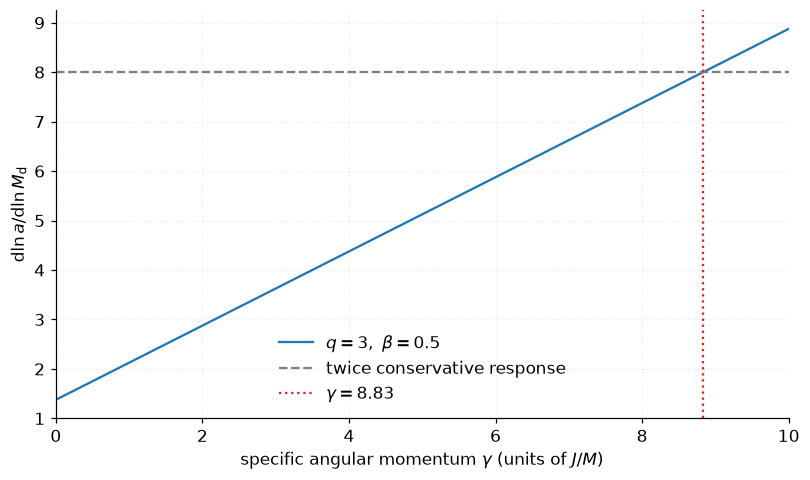

Threshold gamma = 8.833333; response = 8.00


In [56]:
gamma_grid = np.linspace(0, 10, 301)
response = dlna_dlnMd_general(3.0, beta=0.5, gamma=gamma_grid)
target = 2*dlna_dlnMd(3.0)
gamma_target = (target-11/8)/(3/4)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(gamma_grid, response, label=r"$q=3,\ \beta=0.5$")
ax.axhline(target, color="gray", ls="--", label="twice conservative response")
ax.axvline(gamma_target, color="tab:red", ls=":", label=fr"$\gamma={gamma_target:.2f}$")
ax.set(xlabel=r"specific angular momentum $\gamma$ (units of $J/M$)",
       ylabel=r"$\mathrm{d}\ln a/\mathrm{d}\ln M_{\rm d}$", xlim=(0, 10))
ax.legend()
plt.tight_layout()
plt.show()
print(f"Threshold gamma = {gamma_target:.6f}; response = {dlna_dlnMd_general(3, beta=.5, gamma=gamma_target):.2f}")

### Exercise 6 — Connect it to real populations (open-ended)

Open [Notebook 2](analysing_a_population_of_gravitational_wave_sources.ipynb) and look again at
the two "islands" in the separation–mass-ratio plane. Using what you now know:

- Why does the **common envelope** channel end up at much smaller separations?
- The **stable mass transfer** channel produces systems with mass ratios closer to 1. Which part
  of this notebook explains that?
- Careful: the $q$ plotted in Notebook 2 is the *observational* $q = m_2/m_1 \le 1$, not the
  donor/accretor $q$ used here. Does that change your answer?

<a id="glossary"></a>
# Glossary and references

| Term | Meaning |
|---|---|
| **Accretor** | The star *gaining* mass. |
| **Adiabatic response** $\zeta_\star$ | $\mathrm{d}\ln R_\star/\mathrm{d}\ln M$ for a star losing mass faster than it can thermally readjust. Positive for radiative envelopes, $\approx -1/3$ for deep convective ones. |
| **Accretion efficiency** $\beta$ | Fraction of transferred mass the accretor retains. $\beta=1$ is conservative. |
| **Conservative mass transfer** | Neither mass nor angular momentum leaves the binary. |
| **Donor** | The star *losing* mass. Always $\dot M_{\rm d} < 0$. |
| **Isotropic re-emission** | Mass-loss mode where material is ejected from near the accretor; $\gamma = q$. |
| **Jeans mode** | Fast spherical wind straight off the donor; $\gamma = 1/q$. |
| **Logarithmic derivative** | $\mathrm{d}\ln X = \mathrm{d}X/X$. Turns products of powers into sums. |
| **Mass ratio** $q$ | **Here: $M_{\rm donor}/M_{\rm accretor}$.** Conventions differ — always check (§4.1). |
| **Reduced mass** $\mu$ | $M_{\rm d}M_{\rm a}/M$; the effective mass of the equivalent one-body problem. |
| **Roche lobe** | The teardrop region within which a star's gravity dominates. Filling it starts mass transfer. |
| $\zeta_{\rm L}$ | $\mathrm{d}\ln R_{\rm L}/\mathrm{d}\ln M_{\rm d}$ — how fast the Roche lobe closes in. |

### References

- **Onno Pols**, *Binary Stars* lecture notes — the clearest available treatment of this material.
  👉 https://www.astro.ru.nl/~onnop/education/binaries_utrecht_notes/
- **Soberman, Phinney & van den Heuvel (1997)**, *Stability criteria for mass transfer in binary
  stellar evolution*, A&A 327, 620 — the standard reference for the $\beta$/$\gamma$
  parametrisation and the different mass-loss modes. 👉 https://arxiv.org/abs/astro-ph/9703016
- **Eggleton (1983)**, *Approximations to the radii of Roche lobes*, ApJ 268, 368 — the $R_{\rm L}/a$
  fit used in Part 7. 👉 https://ui.adsabs.harvard.edu/abs/1983ApJ...268..368E
- **Tauris & van den Heuvel (2006)**, *Formation and evolution of compact stellar X-ray sources* —
  a thorough review with the full orbital-response algebra. 👉 https://arxiv.org/abs/astro-ph/0303456
- **Team COMPAS (2022)**, *COMPAS methods paper*, ApJS 258, 34 — how a real population synthesis
  code implements all of this. 👉 https://arxiv.org/abs/2109.10352

# ✅ Summary — what you did

1. Wrote down the orbital angular momentum of a circular binary and took its **logarithmic
   derivative** — the workhorse technique for this whole subject.
2. Derived, for **conservative** mass transfer,
   $$\frac{\mathrm{d}a}{a} = 2\,\frac{\mathrm{d}M_{\rm d}}{M_{\rm d}}\,(q-1),
   \qquad q = \frac{M_{\rm d}}{M_{\rm a}}$$
   and read off the sign: **heavier donor → orbit shrinks; lighter donor → orbit widens.**
3. Learned the one-sentence physical reason: $J \propto M_{\rm d}M_{\rm a}\sqrt a$ is fixed, and
   $M_{\rm d}M_{\rm a}$ peaks at equal masses — so $a$ must move the other way.
4. Turned it into Python, verified the algebra two independent ways, and found the **exact**
   solution $a/a_{\rm i} = \left(M_{\rm d,i}M_{\rm a,i}/M_{\rm d}M_{\rm a}\right)^2$, which shows
   every binary **shrinking then widening** through $q=1$.
5. Generalised to **non-conservative** transfer with $\beta$ and $\gamma$, and saw how much the
   critical mass ratio moves.
6. Saw why this orbital response, compared against the donor's own response, is what makes mass
   transfer **stable or unstable** — and hence where **common envelopes** come from.

# ➡️ Where this goes next

Everything here was one binary and one episode. The reason it matters is that these signs,
integrated over millions of binaries, decide which systems end up tight enough to merge as
gravitational-wave sources — the populations you plot in
[Notebook 2](analysing_a_population_of_gravitational_wave_sources.ipynb).

### Questions?

Sign errors in this derivation are a rite of passage — essentially everyone gets $q$ upside down
at least once. If yours came out backwards, or you never got the notebook to run at all, that is
completely fine: bring it to the onboarding meeting.

---
*GROWL onboarding · companion notebook · after Onno Pols' lecture notes and
Soberman, Phinney & van den Heuvel (1997)*